In [8]:
import numpy as np
from scipy.stats import levy, levy_stable

import matplotlib.pyplot as plt

# Levy's Distribution

In [9]:
N = 1_000

## Classic

In [2]:
loc = 0
scale = 1

x = levy.rvs(loc=loc, scale=scale, size=N)

x_vals = np.linspace(.01, 5, N)
pdf = levy.pdf(x_vals, loc=loc, scale=scale)


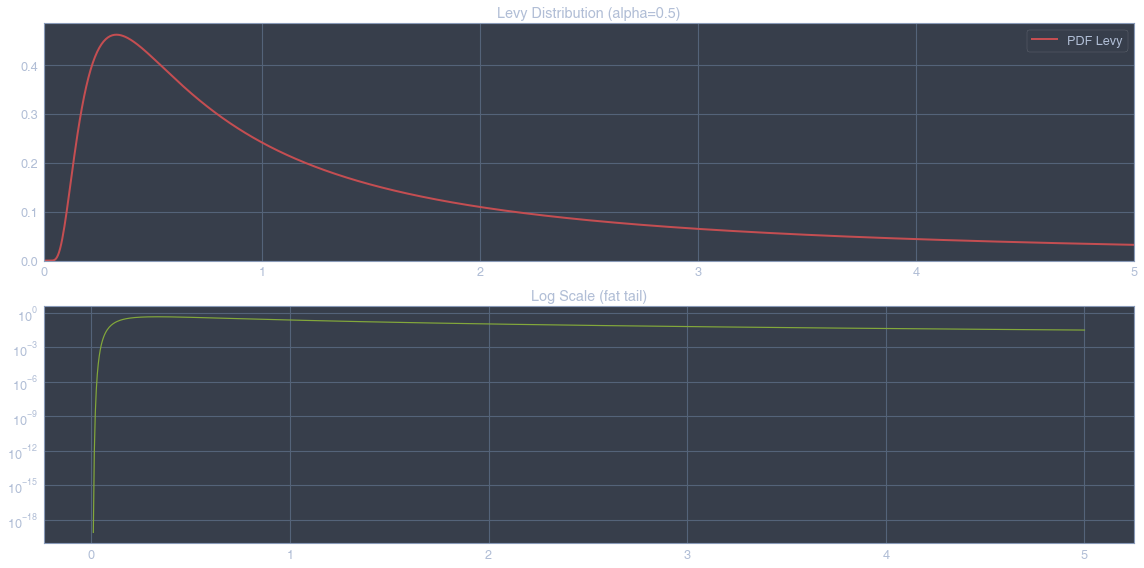

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

axs[0].hist(x, bins=50, density=True, alpha=0.7)
axs[0].plot(x_vals, pdf, 'r-', lw=2, label='PDF Levy')
axs[0].set_title('Levy Distribution (alpha=0.5)')
axs[0].legend()
axs[0].set_xlim(0, 5)

axs[1].plot(x_vals, pdf, 'g-')
axs[1].set_yscale('log')
axs[1].set_title('Log Scale (fat tail)')

plt.tight_layout()

## α-Stable

(0.0, 0.7)

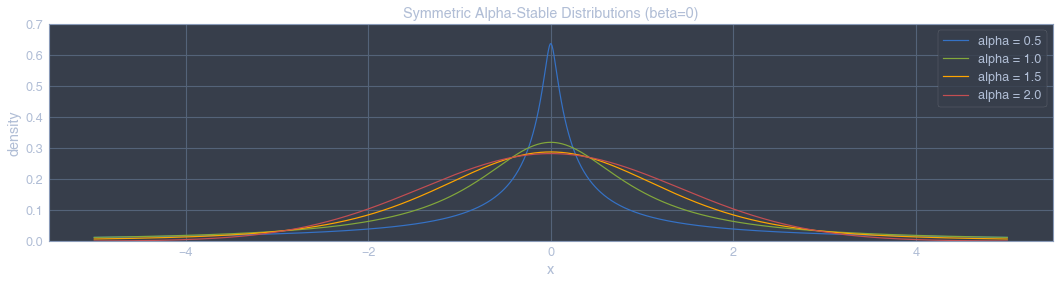

In [13]:
alphas = [.5, 1.0, 1.5, 2.0]
colors = ['b', 'g', 'orange', 'r']
x_vals = np.linspace(-5, 5, N)

plt.figure(figsize=(18, 4))

for alpha, clr in zip(alphas, colors):
    # Стандартная форма: beta=0 (симметричное)
    pdf = levy_stable.pdf(x_vals, alpha, beta=0, loc=0, scale=1)
    plt.plot(x_vals, pdf, color=clr, label=f'alpha = {alpha}')

plt.title('Symmetric Alpha-Stable Distributions (beta=0)')
plt.xlabel('x')
plt.ylabel('density')
plt.legend()
plt.ylim(0, .7)


## Modeling of anomalous diffusion

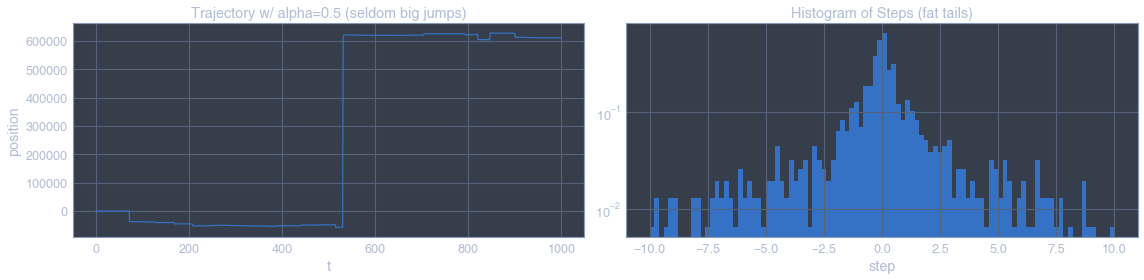

In [15]:
alpha = 0.5
beta = 0
steps = levy_stable.rvs(alpha, beta, size=N, random_state=42)

position = np.cumsum(steps)
time = np.arange(len(position))

fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(time, position)
axs[0].set_title('Trajectory w/ alpha=0.5 (seldom big jumps)')
axs[0].set_xlabel('t')
axs[0].set_ylabel('position')

axs[1].hist(steps, bins=100, density=True, range=(-10, 10))
axs[1].set_title('Histogram of Steps (fat tails)')
axs[1].set_yscale('log')
axs[1].set_xlabel('step')

plt.tight_layout()